<a href="https://colab.research.google.com/github/santhroshan/3D-Color-segementation-to-detect-Diabetic-Retinopathy/blob/main/3D_Color_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the Excel file containing the disease data.


Saving DATASETS.xlsx to DATASETS (1).xlsx
Do you want to upload an image? (yes/no): yes
Please upload the 2D OCTA image.


Saving 10004.bmp to 10004.bmp


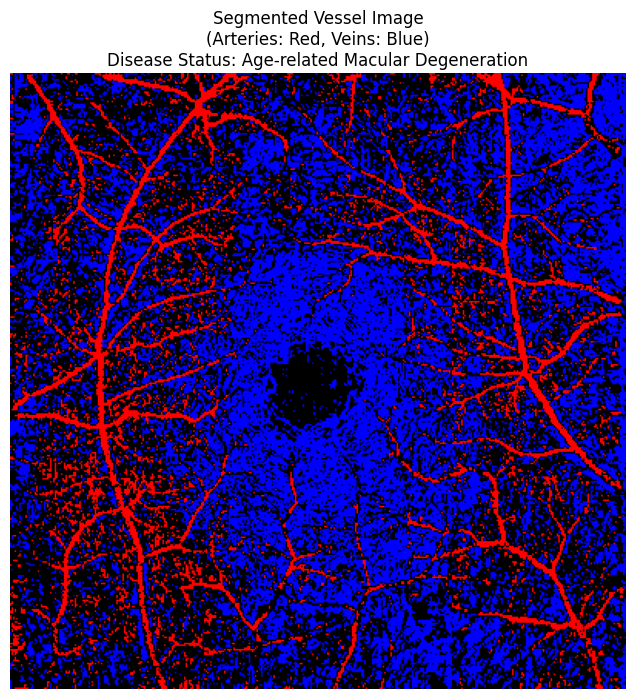

In [ ]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2
import pandas as pd
import re

# Step 2: Upload the Excel file
print("Please upload the Excel file containing the disease data.")
uploaded_excel = files.upload()

# Get the Excel filename
excel_filename = list(uploaded_excel.keys())[0]

# Load the Excel file
df = pd.read_excel(excel_filename)

while True:
    # Step 3: Ask if the user wants to upload an image or stop
    choice = input("Do you want to upload an image? (yes/no): ").strip().lower()
    if choice != 'yes':
        print("Exiting the program.")
        break

    # Step 4: Upload the 2D OCTA image
    print("Please upload the 2D OCTA image.")
    uploaded_image = files.upload()

    # Get the image filename
    image_filename = list(uploaded_image.keys())[0]

    # Extract numeric part from the image filename
    match = re.search(r'\d+', image_filename)
    if match:
        image_id = int(match.group())
    else:
        print("Invalid image filename format. Skipping...")
        continue

    # Step 5: Match image ID with the Excel file
    disease_status = df.loc[df['ID'] == image_id, 'Disease'].values
    if len(disease_status) > 0:
        disease_status = disease_status[0]
    else:
        disease_status = "Unknown"

    # Step 6: Load the image and convert to grayscale
    image = Image.open(image_filename).convert('L')
    image = np.array(image)

    # Step 7: Apply vessel segmentation using thresholding
    # Normalize the image to range [0, 255]
    normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

    # Thresholding to differentiate arteries and veins
    arteries = cv2.inRange(normalized, 180, 255)  # Brighter regions for arteries
    veins = cv2.inRange(normalized, 30, 100)      # Darker regions for veins

    # Step 8: Create a color output
    segmented_image = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    segmented_image[arteries > 0] = [255, 0, 0]  # Red for arteries
    segmented_image[veins > 0] = [0, 0, 255]     # Blue for veins

    # Step 9: Plot the segmented image
    plt.figure(figsize=(8, 8))
    plt.imshow(segmented_image)
    plt.title(f'Segmented Vessel Image\n(Arteries: Red, Veins: Blue)\nDisease Status: {disease_status}')
    plt.axis('off')
    plt.show()